# Medical Insurance Cost Prediction — Model Comparison Study

## Project Overview

The objective of this notebook is to develop an end-to-end machine learning solution for predicting **medical insurance costs** based on demographic and lifestyle attributes such as age, BMI, smoking status, region, and number of dependents.

This notebook consolidates the **entire modeling workflow** into a single, coherent analysis, covering:
- Exploratory Data Analysis (EDA)
- Feature engineering and preprocessing
- Baseline and advanced regression models
- Model evaluation and comparison
- Final model selection based on performance and generalization

Multiple regression approaches are implemented and compared, including:
- Linear Regression
- Ridge Regression
- Support Vector Regression (SVR)
- Decision Tree Regression
- Random Forest Regression
- XGBoost Regression

Each model is evaluated using standard regression performance metrics, and their strengths and limitations are analyzed.  
The notebook concludes with a comparative assessment to identify the model that best balances **predictive performance**, **robustness**, and **interpretability**.

This structured approach demonstrates the full machine learning lifecycle, from data understanding to model selection, in a manner suitable for real-world and production-oriented use cases.



## Dataset Description
Typical variables in this dataset include:
- **age**: Age of primary beneficiary  
- **sex**: Gender of the insurance contractor  
- **bmi**: Body Mass Index  
- **children**: Number of dependents  
- **smoker**: Smoking status  
- **region**: Residential region  
- **charges**: Medical insurance cost (Target Variable)

## 1. Importing Dependencies and Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

plt.rcParams['figure.figsize'] = (8, 5)
sns.set_style("whitegrid")

## 2. Dataset Loading and Initial Inspection

The insurance dataset contains demographic, lifestyle, and regional attributes of individuals along with their corresponding medical insurance charges.  
Initial inspection is performed to understand the structure, data types, and completeness of the dataset.

In [2]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.shape

(1338, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.nunique()

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

In [6]:
df.region.value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [7]:
df.sex.value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [8]:
df.smoker.value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [9]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


<Axes: xlabel='age', ylabel='charges'>

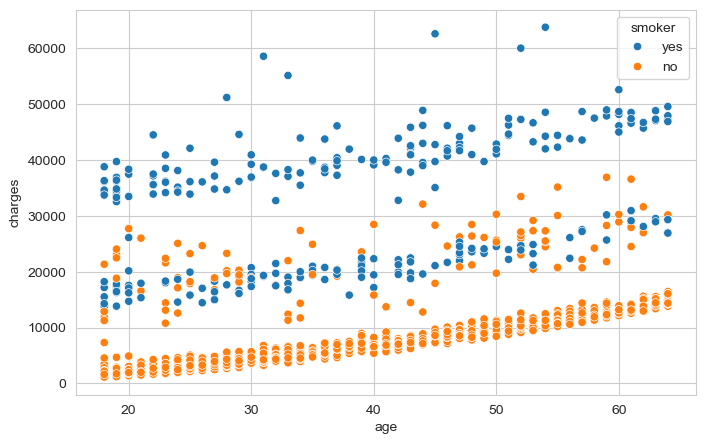

In [10]:
sns.scatterplot(x=df['age'], y=df['charges'], hue=df['smoker'] )

### Distribution of Charges

Text(0.5, 1.0, 'Distribution Of Medical Insurance Charges')

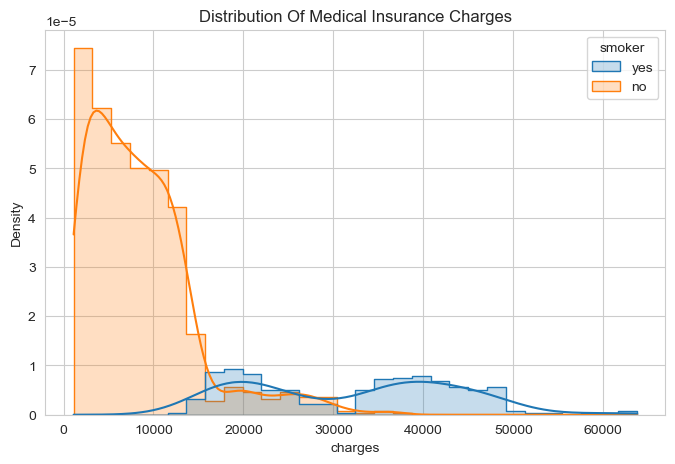

In [11]:
sns.histplot(
    data=df,
    x='charges',
    kde=True,
    hue='smoker',
    stat='density',
    element='step'
)
plt.title("Distribution Of Medical Insurance Charges")

## 3. Target Variable Transformation

**Why Log Transformation?**

Medical insurance charges typically exhibit:

- Strong **right skewness**
- **Heteroscedasticity** (variance increases with mean)

A log transformation:

- Stabilizes variance
- Improves linearity
- Makes residuals closer to normal (important for linear models)

We create a new transformed target:

> **`log(charges)`**

In [12]:
df['log_charges'] = np.log(df['charges'])
df[['charges', 'log_charges']].head()

,charges,log_charges
0,16884.92400,9.734176
1,1725.55230,7.453302
2,4449.46200,8.400538
3,21984.47061,9.998092
4,3866.85520,8.260197


In [13]:
df[['charges', 'log_charges']].describe()

,charges,log_charges
count,1338.000000,1338.000000
mean,13270.422265,9.098659
std,12110.011237,0.919527
min,1121.873900,7.022756
25%,4740.287150,8.463853
50%,9382.033000,9.146552
75%,16639.912515,9.719558
max,63770.428010,11.063045



### Key Observations
- **Charges** are highly skewed with extreme outliers  
- **Log-charges** exhibit a more symmetric distribution  
- Mean and median are closer after log transformation  

This suggests **log(charges)** is more suitable for:
- Linear Regression  
- Regularized models  
- Statistical inference


### 4(a). Distribution of Charges vs Smoker

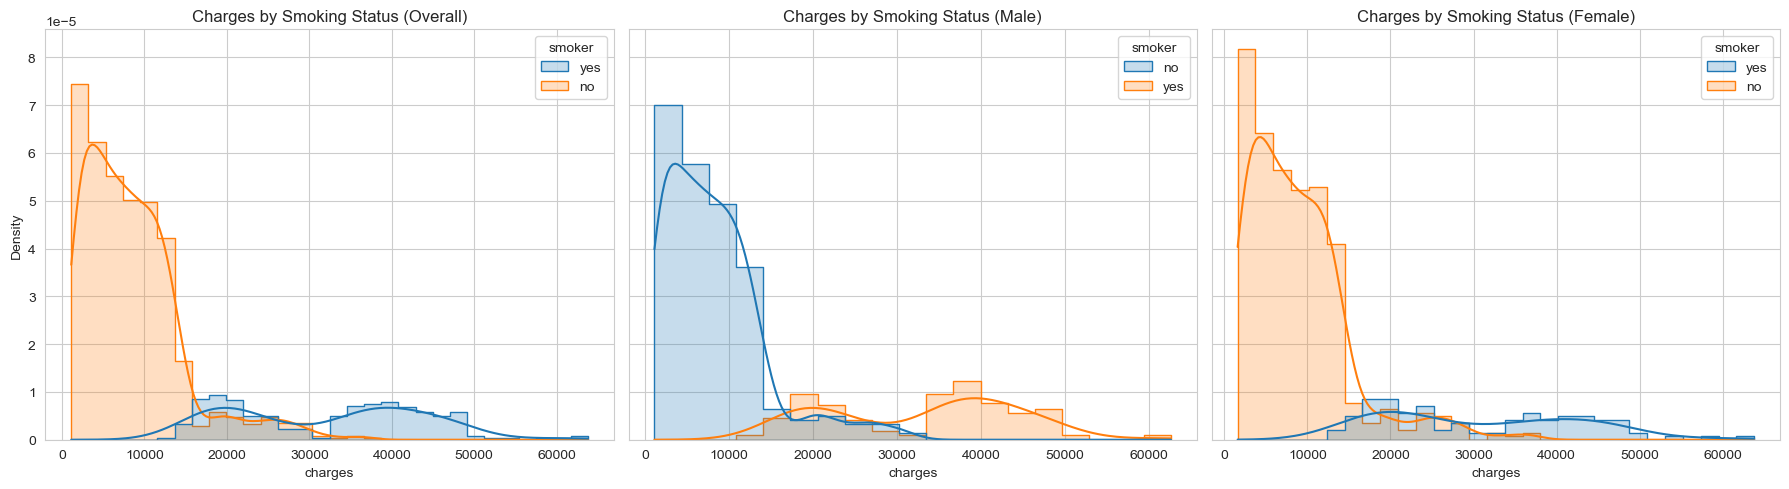

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Overall
sns.histplot(
    data=df, 
    x='charges',
    kde=True, 
    hue='smoker',
    element='step',
    stat='density',
    ax=axes[0]
)
axes[0].set_title('Charges by Smoking Status (Overall)')

# Male only
sns.histplot(
    data=df[df.sex == 'male'], 
    x='charges',
    kde=True, 
    hue='smoker',
    element='step', 
    stat='density',
    ax=axes[1]
)
axes[1].set_title('Charges by Smoking Status (Male)')

# Female only
sns.histplot(
    data=df[df.sex == 'female'], 
    x='charges',
    kde=True,
    hue='smoker',
    element='step',
    stat='density',
    ax=axes[2]
)
axes[2].set_title('Charges by Smoking Status (Female)')

plt.tight_layout()
plt.show()

### 4(b). Distribution of Log Charges vs Smoker

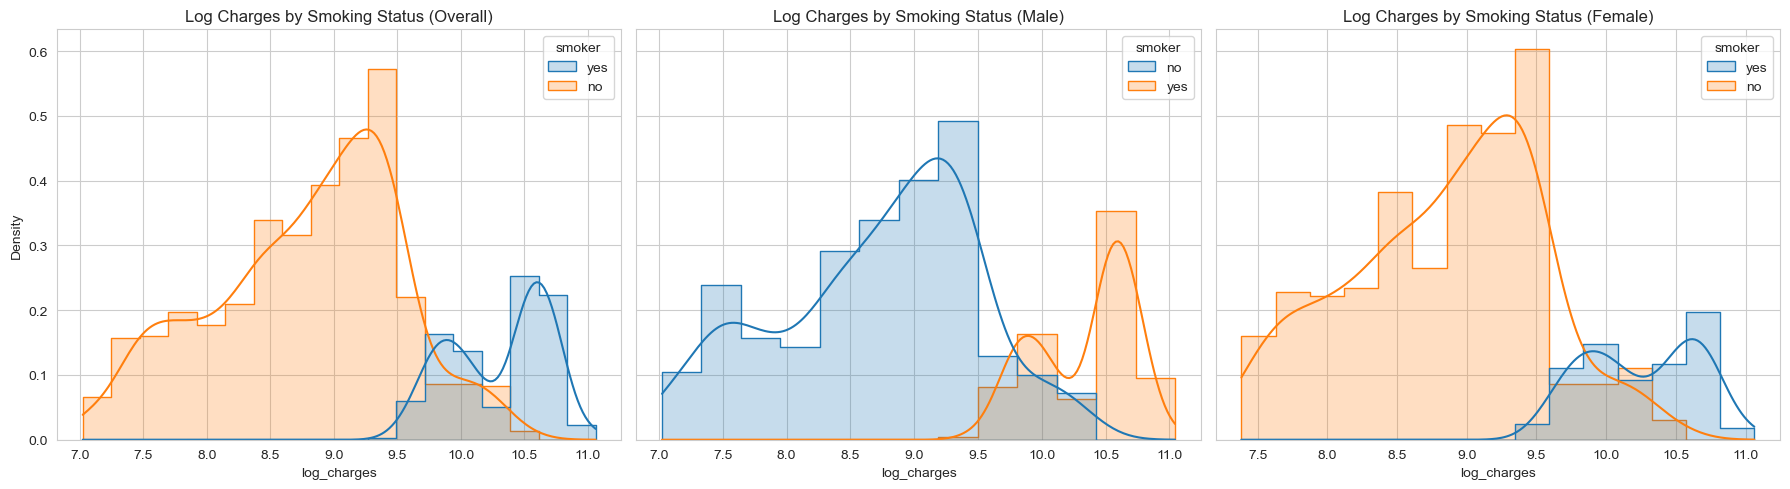

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Overall
sns.histplot(
    data=df,
    x='log_charges',
    kde=True,
    hue='smoker',
    element='step',
    stat='density',
    ax=axes[0]
)
axes[0].set_title('Log Charges by Smoking Status (Overall)')

# Male only
sns.histplot(
    data=df[df.sex == 'male'],
    x='log_charges',
    kde=True,
    hue='smoker',
    element='step',
    stat='density',
    ax=axes[1]
)
axes[1].set_title('Log Charges by Smoking Status (Male)')

# Female only
sns.histplot(
    data=df[df.sex == 'female'],
    x='log_charges',
    kde=True,
    hue='smoker',
    element='step',
    stat='density',
    ax=axes[2]
)
axes[2].set_title('Log Charges by Smoking Status (Female)')

plt.tight_layout()
plt.show()


## 5. Correlation Analysis

In [16]:
# Select relevant columns
df_corr = df.copy()

In [17]:
# One-hot encoding categorical variables
df_corr_encoded = pd.get_dummies(
    df_corr,
    columns=['sex', 'smoker', 'region'],
    #drop_first=True
)

In [18]:
# Correlation matrix
corr_matrix = df_corr_encoded.corr()
corr_matrix

,age,bmi,children,charges,log_charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
age,1.000000,0.109272,0.042469,0.299008,0.527834,0.020856,-0.020856,0.025019,-0.025019,0.002475,-0.000407,-0.011642,0.010016
bmi,0.109272,1.000000,0.012759,0.198341,0.132669,-0.046371,0.046371,-0.003750,0.003750,-0.138156,-0.135996,0.270025,-0.006205
children,0.042469,0.012759,1.000000,0.067998,0.161336,-0.017163,0.017163,-0.007673,0.007673,-0.022808,0.024806,-0.023066,0.021914
charges,0.299008,0.198341,0.067998,1.000000,0.892964,-0.057292,0.057292,-0.787251,0.787251,0.006349,-0.039905,0.073982,-0.043210
log_charges,0.527834,0.132669,0.161336,0.892964,1.000000,-0.005632,0.005632,-0.665506,0.665506,0.043115,-0.017824,0.015791,-0.041632
sex_female,0.020856,-0.046371,-0.017163,-0.057292,-0.005632,1.000000,-1.000000,0.076185,-0.076185,0.002425,0.011156,-0.017117,0.004184
sex_male,-0.020856,0.046371,0.017163,0.057292,0.005632,-1.000000,1.000000,-0.076185,0.076185,-0.002425,-0.011156,0.017117,-0.004184
smoker_no,0.025019,-0.003750,-0.007673,-0.787251,-0.665506,0.076185,-0.076185,1.000000,-1.000000,-0.002811,0.036945,-0.068498,0.036945
smoker_yes,-0.025019,0.003750,0.007673,0.787251,0.665506,-0.076185,0.076185,-1.000000,1.000000,0.002811,-0.036945,0.068498,-0.036945
region_northeast,0.002475,-0.138156,-0.022808,0.006349,0.043115,0.002425,-0.002425,-0.002811,0.002811,1.000000,-0.320177,-0.345561,-0.320177


### Correlation Heatmap

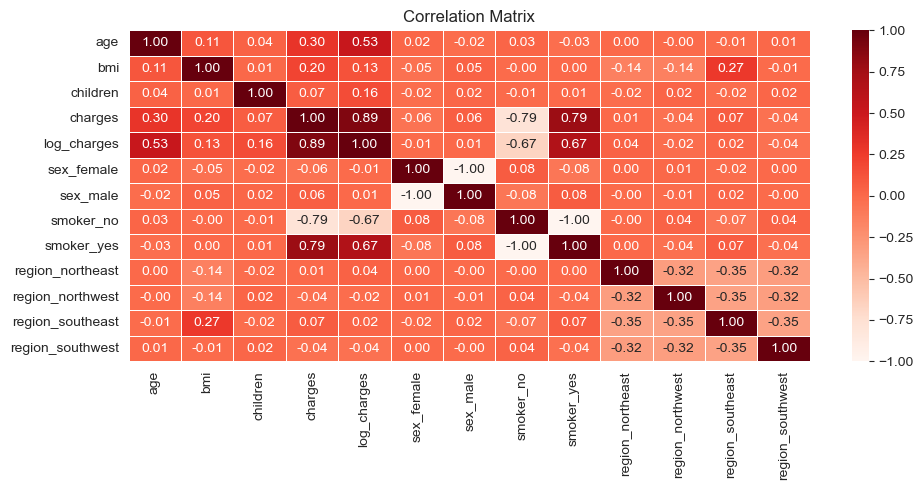

In [19]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    corr_matrix,
    cmap='Reds',
    annot=True,
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 6. Features and Targets

In [20]:
# Features
X = df.drop(['charges', 'log_charges'], axis=1)

# Target
y_log = df['log_charges']
y_raw = df['charges']

#### Categorical Feature Encoding

The dataset contains both numerical and categorical variables.  
Since machine learning models require numerical inputs, categorical variables must be encoded appropriately.

To avoid introducing artificial ordering and data leakage, categorical variables are encoded using **One-Hot Encoding** within a preprocessing pipeine.
.


In [21]:
# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target variables from numerical list
numerical_cols.remove('charges')
numerical_cols.remove('log_charges')

In [22]:
print("Categorical Features : ",categorical_cols)
print("Numerical Features : ", numerical_cols)

Categorical Features :  ['sex', 'smoker', 'region']
Numerical Features :  ['age', 'bmi', 'children']


## 7. Train-Test-Split

In [23]:
# Split the data using ONLY the raw target
X_train, X_test, y_train, y_test = train_test_split(
    X, y_raw, test_size=0.20, random_state=42
)

## 8. Importing Models

In [31]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

## 9. Column Transformation and Preprocessing

In [33]:
# 1. Preprocessor with scaling (For Linear, Ridge, SVR)
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
        ('num', MinMaxScaler(), numerical_cols)
    ]
)

# 2. Preprocessor WITHOUT Scaling (For Trees & Ensembles)
# We use 'passthrough' so the numerical columns are left raw
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numerical_cols) 
    ]
)

# 3. Mapping models to their correct preprocessor
models = {
    "Linear Regression": (LinearRegression(), preprocessor_scaled),
    "Ridge Regression": (Ridge(random_state=42), preprocessor_scaled),
    "SVR": (SVR(), preprocessor_scaled),
    "Decision Tree": (DecisionTreeRegressor(random_state=42), preprocessor_tree),
    "Random Forest": (RandomForestRegressor(random_state=42), preprocessor_tree),
    "XGBoost Regressor": (XGBRegressor(random_state=42, objective='reg:squarederror'), preprocessor_tree)
}

## 10. Base Model Training and Evaluation

In [36]:
# Loop through and evaluate
results = {}

for name, (model, preprocessor) in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessing', preprocessor),
        ('regressor', model)
    ])
    
    wrapped_model = TransformedTargetRegressor(
        regressor=pipeline,
        func=np.log,
        inverse_func=np.exp
    )
    # Train the wrapped model
    wrapped_model.fit(X_train, y_train)

    # Predict on train data
    train_pred = wrapped_model.predict(X_train)
    
    # Predict on test data
    test_pred = wrapped_model.predict(X_test)
    
    # Calculate metrics
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    
    # Store and print results
    results[name] = {'Train R2': train_r2, 'Test R2': test_r2, 'Test RMSE': test_rmse}
    
    print(f"{name}:")
    print(f"  Train R2:   {train_r2:.4f}")
    print(f"  Test R2:   {test_r2:.4f}")
    print(f"  Test RMSE: {test_rmse:.4f}\n")

# Convert results to a pandas DataFrame
results_df = pd.DataFrame(results).T.sort_values(by='Test R2', ascending=False)
print("-" * 40)
print("Final Rankings (Best to Worst R2):")
print(results_df)

Linear Regression:
  Train R2:   0.5122
  Test R2:   0.6066
  Test RMSE: 7815.3073

Ridge Regression:
  Train R2:   0.5248
  Test R2:   0.6163
  Test RMSE: 7718.0936

SVR:
  Train R2:   0.8321
  Test R2:   0.8610
  Test RMSE: 4644.7525

Decision Tree:
  Train R2:   0.9979
  Test R2:   0.7826
  Test RMSE: 5809.4156

Random Forest:
  Train R2:   0.9595
  Test R2:   0.8773
  Test RMSE: 4363.9551

XGBoost Regressor:
  Train R2:   0.9905
  Test R2:   0.8395
  Test RMSE: 4991.1426

----------------------------------------
Final Rankings (Best to Worst R2):
                   Train R2   Test R2    Test RMSE
Random Forest      0.959503  0.877332  4363.955141
SVR                0.832056  0.861038  4644.752458
XGBoost Regressor  0.990489  0.839538  4991.142556
Decision Tree      0.997872  0.782611  5809.415611
Ridge Regression   0.524785  0.616300  7718.093614
Linear Regression  0.512165  0.606573  7815.307271


**TransformedTargetRegressor** is one of **Scikit-Learn's** most useful hidden gems. It acts as a **"wrapper"** around them machine learning model.

Instead of manually creating `y_log`, managing separate target variables, and remembering to apply `np.exp()` at the end, this tool does it all automatically in the background.

Here is how it changes the workflow:

- Give it the raw, un-transformed y data.

- After calling `.fit()`, it automatically applies `np.log` to `y` and trains the model.

- After calling `.predict()`, it makes the prediction and automatically applies `np.exp()` to the output, handing back the real currency values.

After looking at the performance of baseline models with **default parameters**, we can clearly see that **Random Forest** already beats other models in terms of **Test R2 Score** which implies that it best generalizes the learning.
- Now applying **hyperparameter tuning** to **Random Forest Model** to squeeze out the final bit of performance:

In [37]:
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numerical_cols) 
    ]
)

pipeline_rf = Pipeline(steps=[
    ('preprocessing', preprocessor_tree),
    ('model', RandomForestRegressor(random_state=42))
])

# Wrapping it in TransformedTargetRegressor
# use log for training, and exp for predicting
final_model = TransformedTargetRegressor(
    regressor=pipeline_rf,
    func=np.log,
    inverse_func=np.exp
)

In [38]:
# Define the hyperparameter search space
# CRITICAL SYNTAX: Because the RandomForest is now inside the wrapper, 
# 'regressor__' targets the pipeline inside the TransformedTargetRegressor
# 'model__' targets the RandomForest step inside the pipeline
param_dist = {
    'regressor__model__n_estimators': [100, 200, 300, 400],
    'regressor__model__max_depth': [None, 5, 10, 15],
    'regressor__model__min_samples_split': [2, 5, 10],
    'regressor__model__max_features': ['sqrt', 'log2', None]
}

# Set up the Randomized Search
random_search = RandomizedSearchCV(
    estimator=final_model,
    param_distributions=param_dist,
    n_iter=20,          # Try 20 random combinations
    cv=5,               # 5-fold cross validation
    scoring='neg_mean_squared_error',
    n_jobs=-1,          # Use all CPU cores
    random_state=42,
    verbose=1           # Prints progress updates
)

In [39]:
print("Starting the hyperparameter search... This may take a few minutes.")
# Feed it the RAW y_train data!
random_search.fit(X_train, y_train)

Starting the hyperparameter search... This may take a few minutes.
Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,TransformedTa..._state=42))]))
,param_distributions,"{'regressor__model__max_depth': [None, 5, ...], 'regressor__model__max_features': ['sqrt', 'log2', ...], 'regressor__model__min_samples_split': [2, 5, ...], 'regressor__model__n_estimators': [100, 200, ...]}"
,n_iter,20
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [43]:
best_tuned_model = random_search.best_estimator_

print("\nBest Parameters Found:")
# This prints the best combination which gives highest R2 score
print(random_search.best_params_)


Best Parameters Found:
{'regressor__model__n_estimators': 300, 'regressor__model__min_samples_split': 5, 'regressor__model__max_features': None, 'regressor__model__max_depth': 5}


In [44]:
# Final Evaluation on the Test Set
y_pred = best_tuned_model.predict(X_test)

tuned_r2 = r2_score(y_test, y_pred)
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nTuned Random Forest Test R2:   {tuned_r2:.4f}")
print(f"Tuned Random Forest Test RMSE: {tuned_rmse:.4f}")


Tuned Random Forest Test R2:   0.8760
Tuned Random Forest Test RMSE: 4387.4364


Clearly, tuned model has a lower $R^2$ and a higher RMSE than the default model, one of these three things likely happened:

**1. Search Space Excluded the Default (and the default was better) :**
The default settings in scikit-learn are chosen by the developers because they mathematically work incredibly well for a wide majority of datasets.
- For example, the default max_depth for a Random Forest is None (meaning the trees grow as deep as they want until all leaves are pure). If we set our search space to 'max_depth': [5, 10, 15, 20], we have literally blocked the algorithm from using its default behavior. If our specific dataset actually required a depth of 25 to capture the complex smoker/BMI interactions, the "tuned" model will underperform because we put an artificial ceiling on it.

**2. Overfitting the Cross-Validation Folds :**
During RandomizedSearchCV, the algorithm is trying to find the parameters that get the highest average score across the 5 cross-validation folds in the training data.
- When we test 20 or 50 different parameter combinations, sometimes a specific combination just gets "lucky." It happens to perfectly map the quirks of those specific 5 folds, scoring incredibly high during the search. But when we apply those parameters to the unseen, held-out test set, that "luck" runs out. The default model, while less fine-tuned to the training data, might have generalized better to the test set.

**3. The Log-Transform Scoring Mismatch (Specific to your code) :**
Because the model is wrapped in TransformedTargetRegressor, there is a sneaky mathematical quirk happening in the background during the tuning phase. RandomizedSearchCV is scoring the models using 'neg_mean_squared_error' on the log-transformed training data. It finds the parameters that minimize the error in log-space. However, the final evaluation calculates RMSE and $R^2$ on the raw, exponentiated test data. The parameters that perfectly minimize error on a tight, symmetric log distribution are not mathematically guaranteed to be the exact same parameters that minimize error on a massive, skewed raw currency distribution.

In [49]:

fitted_pipeline = best_tuned_model.regressor_

# Feature Importance
importances = fitted_pipeline.named_steps['model'].feature_importances_

cat_features = fitted_pipeline.named_steps['preprocessing'] \
    .named_transformers_['cat'] \
    .get_feature_names_out(categorical_cols)

feature_names = list(cat_features) + numerical_cols

rf_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

rf_importance_df

,Feature,Importance
1,smoker_yes,0.508234
5,age,0.403890
6,bmi,0.044441
7,children,0.034956
0,sex_male,0.003677
2,region_northwest,0.002869
4,region_southwest,0.001288
3,region_southeast,0.000645


C:\Users\Rishabh\AppData\Local\Temp\ipykernel_17416\4247486760.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


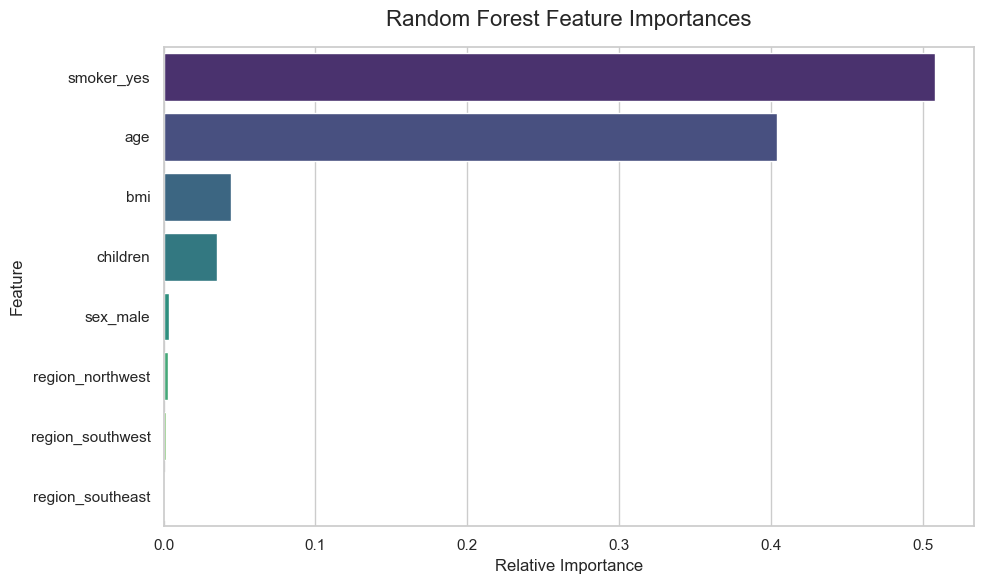

In [52]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x='Importance', 
    y='Feature', 
    data=rf_importance_df,
    palette='viridis'
)

plt.title('Random Forest Feature Importances', fontsize=16, pad=15)
plt.xlabel('Relative Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)

plt.tight_layout()

plt.show()